In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [288]:
marketing_data = pd.read_csv("../data/dataset.csv")
marketing_data.head()

,occupation,age,education_level,marital_status,communication_channel,call_month,call_day,call_duration,call_frequency,previous_campaign_outcome,conversion_status
0,administrative_staff,28,high_school,married,unidentified,September,9,1,1,successful,not_converted
1,administrative_staff,58,unidentified,married,unidentified,June,5,307,2,unidentified,not_converted
2,jobless,40,high_school,divorced,mobile,February,4,113,1,unidentified,not_converted
3,retired_worker,63,high_school,married,mobile,April,7,72,5,unidentified,not_converted
4,business_owner,43,college,married,landline,July,29,184,4,unidentified,not_converted


## Understanding data

In [289]:
print(f'Data has {marketing_data.shape[0]} rows and {marketing_data.shape[1]} columns')

Data has 45211 rows and 11 columns


In [290]:
print("Columns:", marketing_data.columns)

Columns: Index(['occupation', 'age', 'education_level', 'marital_status',
       'communication_channel', 'call_month', 'call_day', 'call_duration',
       'call_frequency', 'previous_campaign_outcome', 'conversion_status'],
      dtype='str')


In [291]:
marketing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   occupation                 45211 non-null  str  
 1   age                        45211 non-null  int64
 2   education_level            45211 non-null  str  
 3   marital_status             45211 non-null  str  
 4   communication_channel      45211 non-null  str  
 5   call_month                 45211 non-null  str  
 6   call_day                   45211 non-null  int64
 7   call_duration              45211 non-null  int64
 8   call_frequency             45211 non-null  int64
 9   previous_campaign_outcome  45211 non-null  str  
 10  conversion_status          45211 non-null  str  
dtypes: int64(4), str(7)
memory usage: 3.8 MB


In [292]:
# Checking null values
marketing_data.isnull().sum()

occupation                   0
age                          0
education_level              0
marital_status               0
communication_channel        0
call_month                   0
call_day                     0
call_duration                0
call_frequency               0
previous_campaign_outcome    0
conversion_status            0
dtype: int64

In [293]:
marketing_data.duplicated().sum()

np.int64(6)

In [294]:
# Dropped duplicate values 
marketing_data.drop_duplicates(inplace=True)

In [295]:
marketing_data.duplicated().sum()

np.int64(0)

In [296]:
marketing_data.describe()

,age,call_day,call_duration,call_frequency
count,45205.000000,45205.00000,45205.000000,45205.000000
mean,40.937087,15.80688,258.183055,2.763898
std,10.619130,8.32234,257.538504,3.098189
min,18.000000,1.00000,0.000000,1.000000
25%,33.000000,8.00000,103.000000,1.000000
50%,39.000000,16.00000,180.000000,2.000000
75%,48.000000,21.00000,319.000000,3.000000
max,95.000000,31.00000,4918.000000,63.000000


## Exploratory Data Analysis

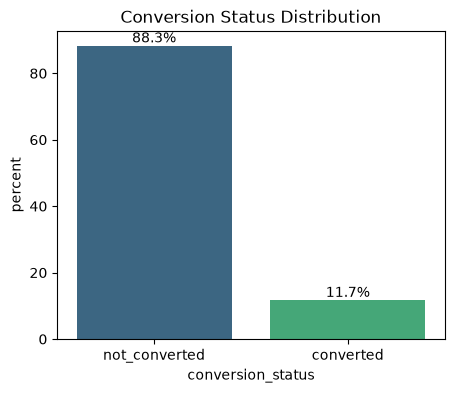

In [297]:
# Conversion Status Distribution (Target Analysis)
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='conversion_status', data=marketing_data, stat='percent', palette='viridis', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Conversion Status Distribution')
plt.savefig('../images/1.conversion_status_distribution.png', bbox_inches='tight')
plt.show()

In [298]:
# Numerical and Categorical Columns
numerical_columns = marketing_data.select_dtypes(include=['number']).columns.to_list()
categorical_columns = marketing_data.select_dtypes(include=['string']).columns.to_list()

print(f'We have {len(numerical_columns)} numerical columns: {numerical_columns}')
print(f'We have {len(categorical_columns)} categorical columns: {categorical_columns}')

We have 4 numerical columns: ['age', 'call_day', 'call_duration', 'call_frequency']
We have 7 categorical columns: ['occupation', 'education_level', 'marital_status', 'communication_channel', 'call_month', 'previous_campaign_outcome', 'conversion_status']


**Univariate Analysis**

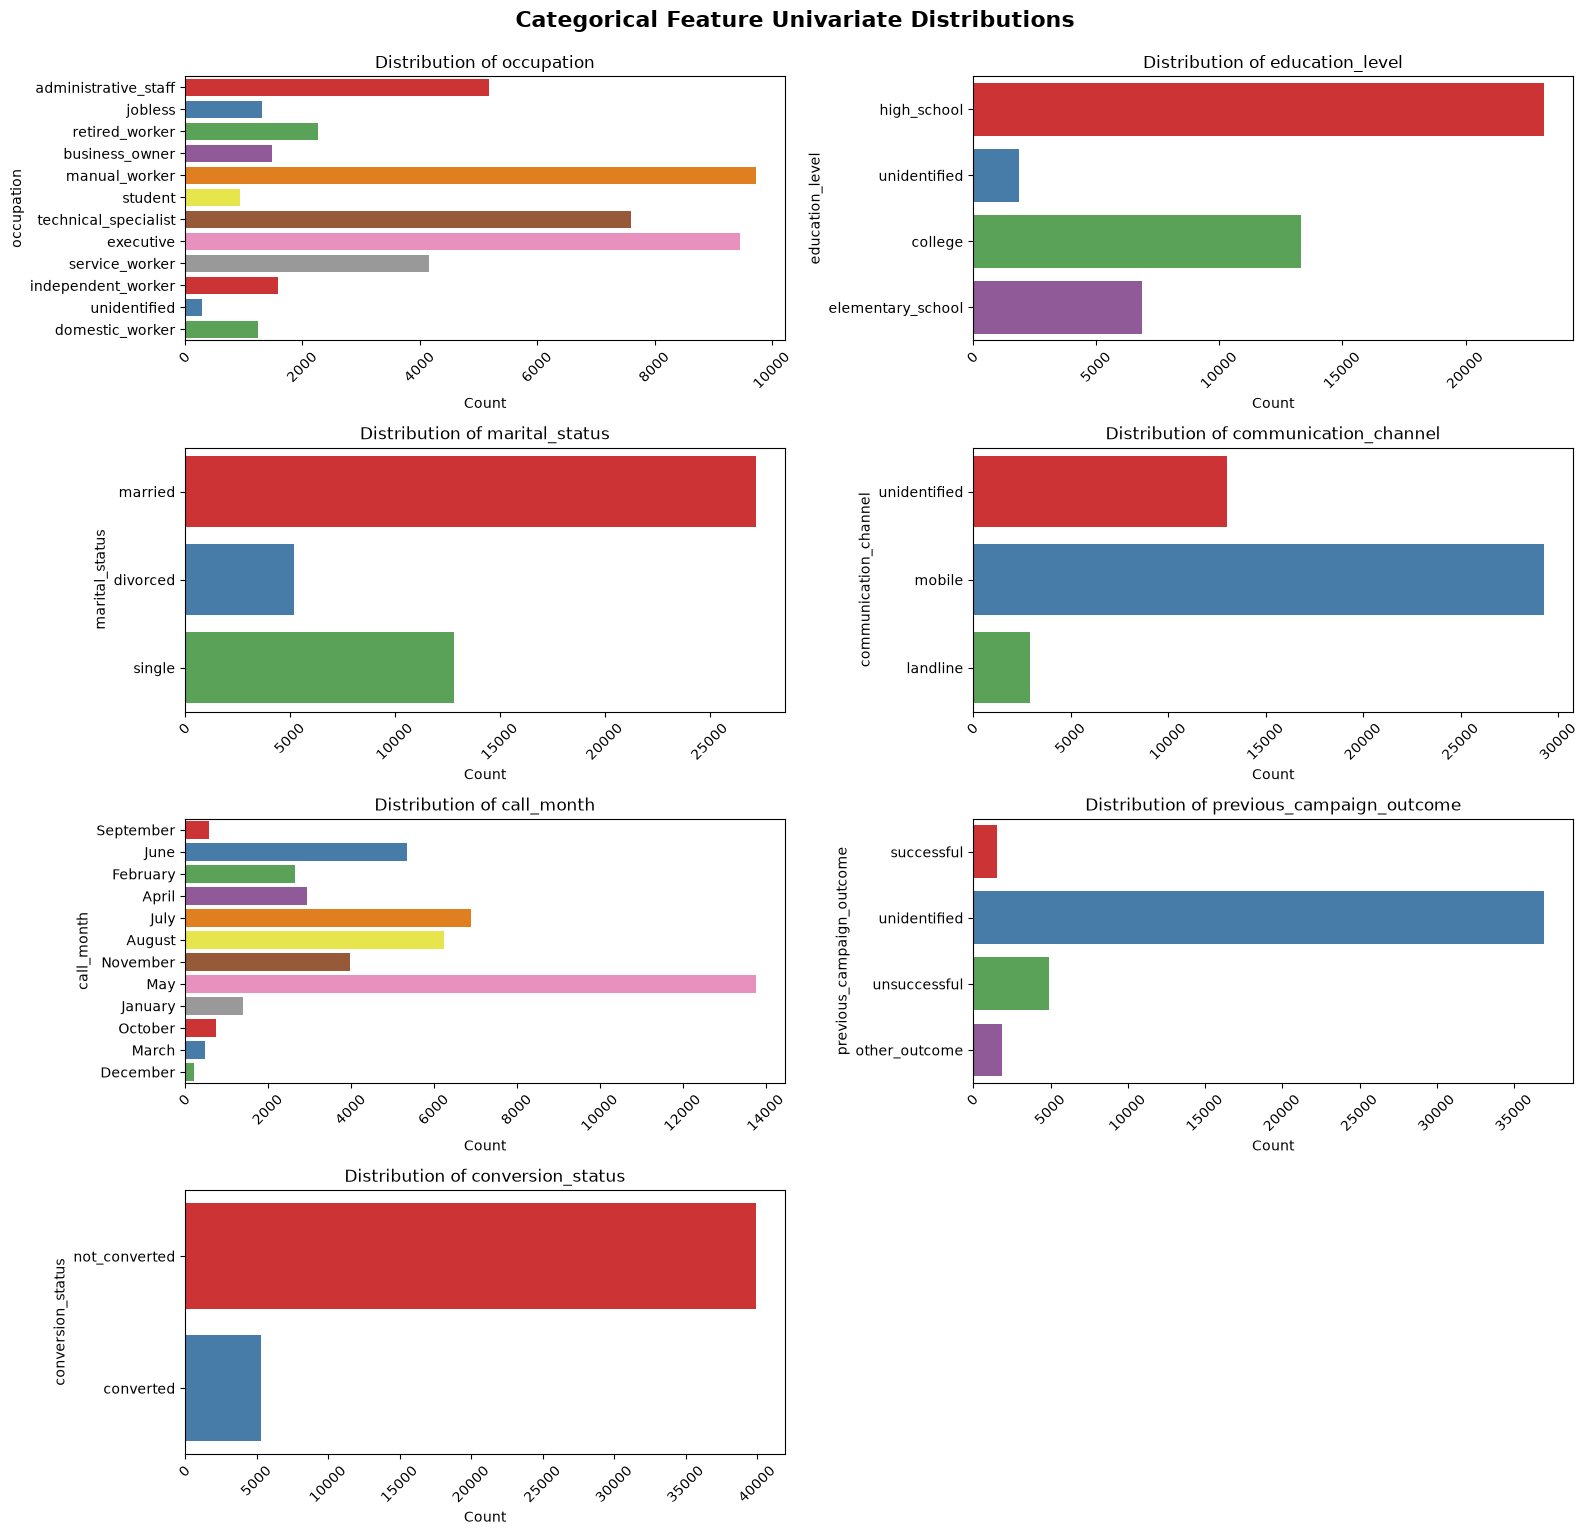

In [299]:
# Visualizing Categorical Feature Distributions
plt.figure(figsize=(16, 15))
for i, feature in enumerate(categorical_columns, 1):
    plt.subplot(4, 2, i)
    sns.countplot(data=marketing_data, y=feature, palette='Set1')
    plt.title(f'Distribution of {feature}')
    plt.xlabel('Count')
    plt.ylabel(feature)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Univariate Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/2.categorical_feature_univariate_distributions.png', bbox_inches='tight')
plt.show()


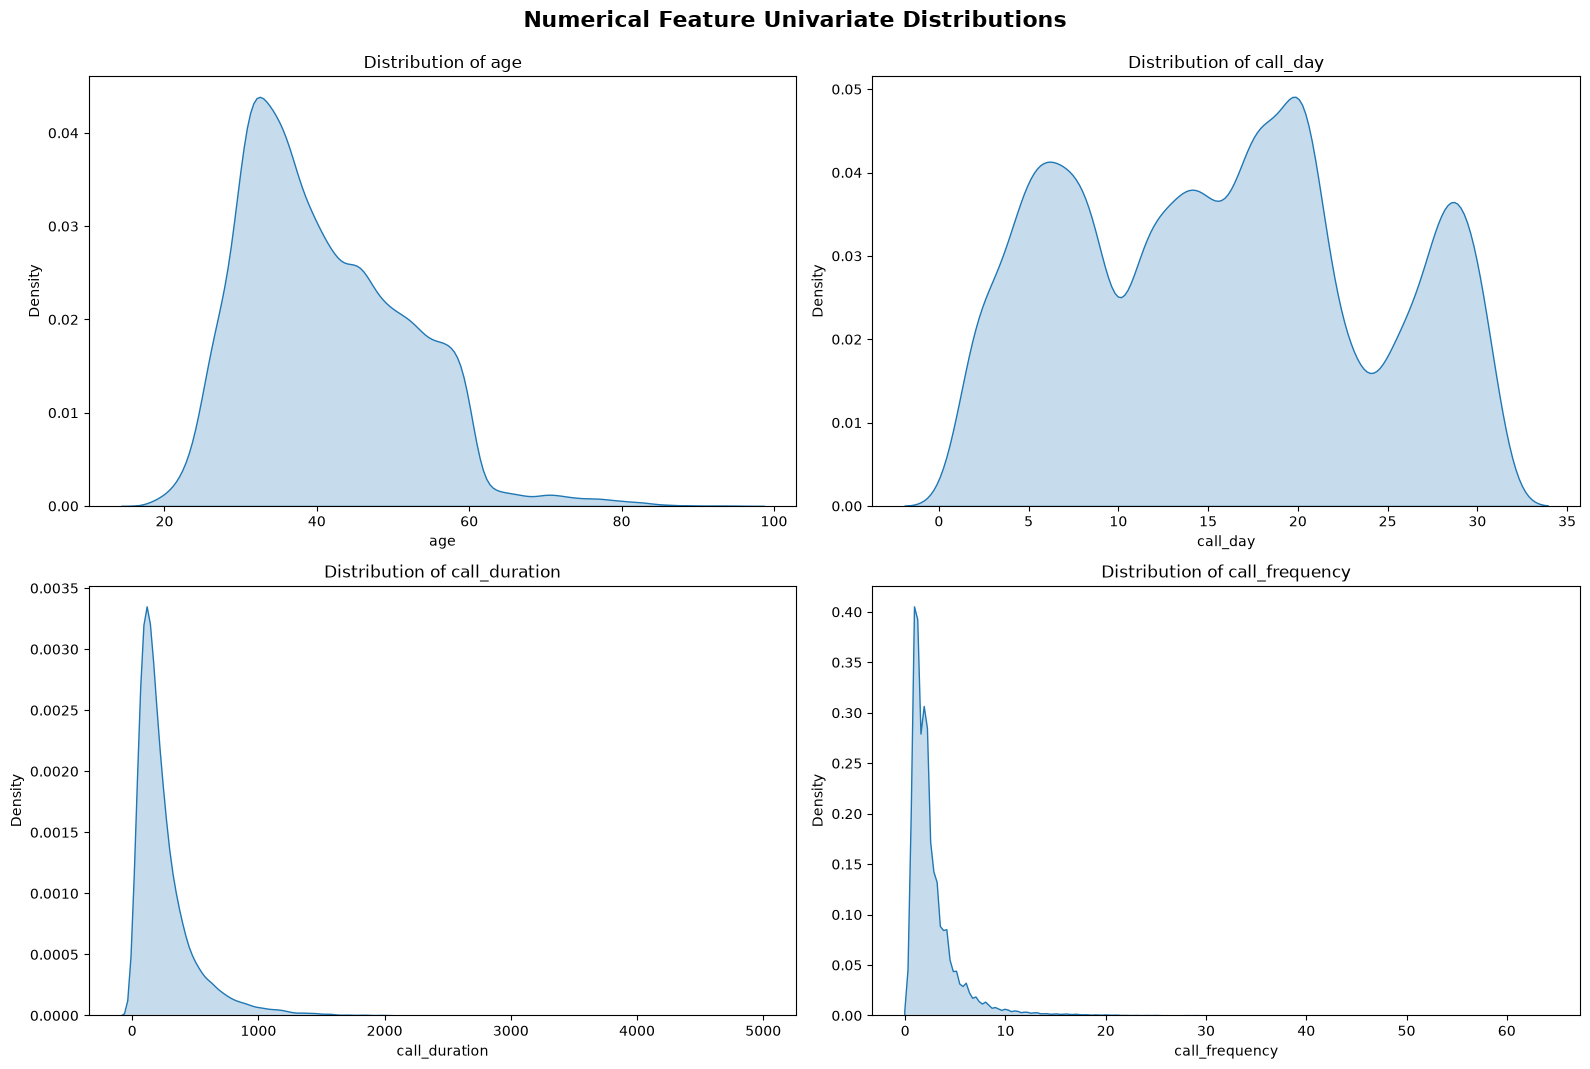

In [300]:
# Visualizing Numerical Feature Distributions

plt.figure(figsize=(16, 15))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=marketing_data, x=feature, fill=True, common_norm=False)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Numerical Feature Univariate Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/3.numerical_feature_univariate_distributions.png', bbox_inches='tight')
plt.show()

**Bivariate Analysis**

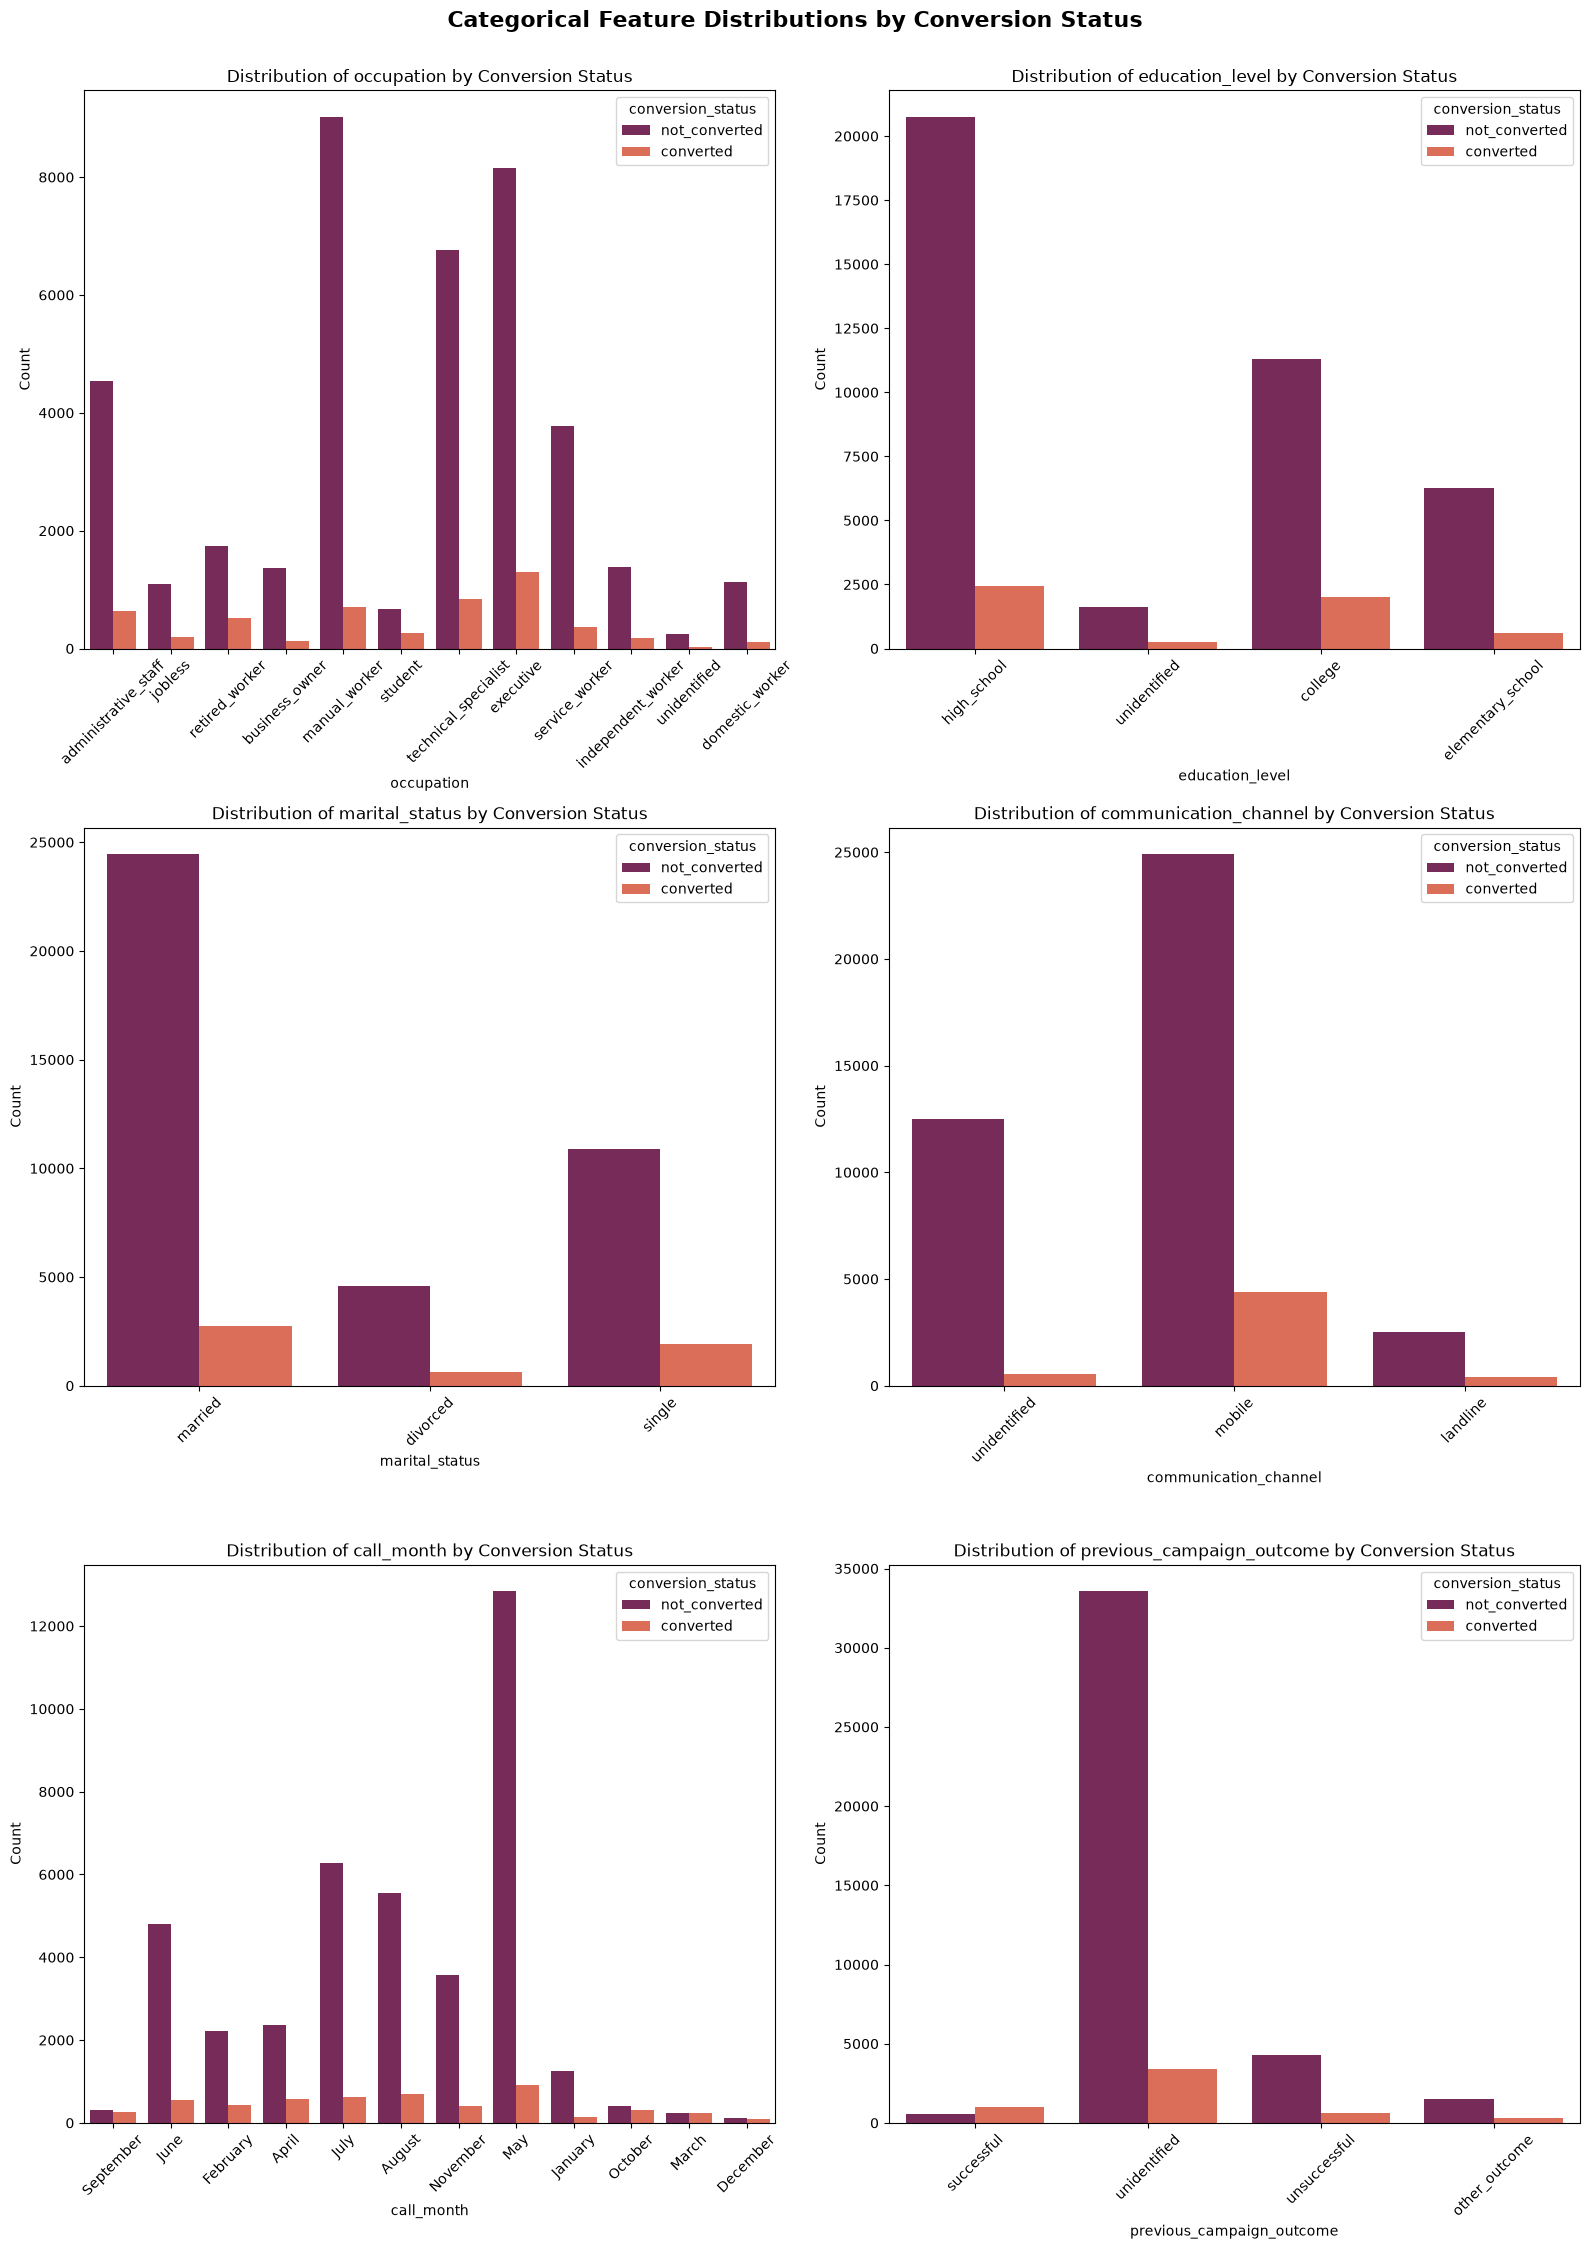

In [301]:
# Visualizing Categorical Feature Distributions by Conversion Status
plt.figure(figsize=(16, 22))

categorical_features = [column for column in categorical_columns if column != "conversion_status"]

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=marketing_data, x=feature, hue='conversion_status', palette='rocket')
    plt.title(f'Distribution of {feature} by Conversion Status')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Distributions by Conversion Status", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/4.categorical_feature_distributions_by_conversion_status.png', bbox_inches='tight')
plt.show()


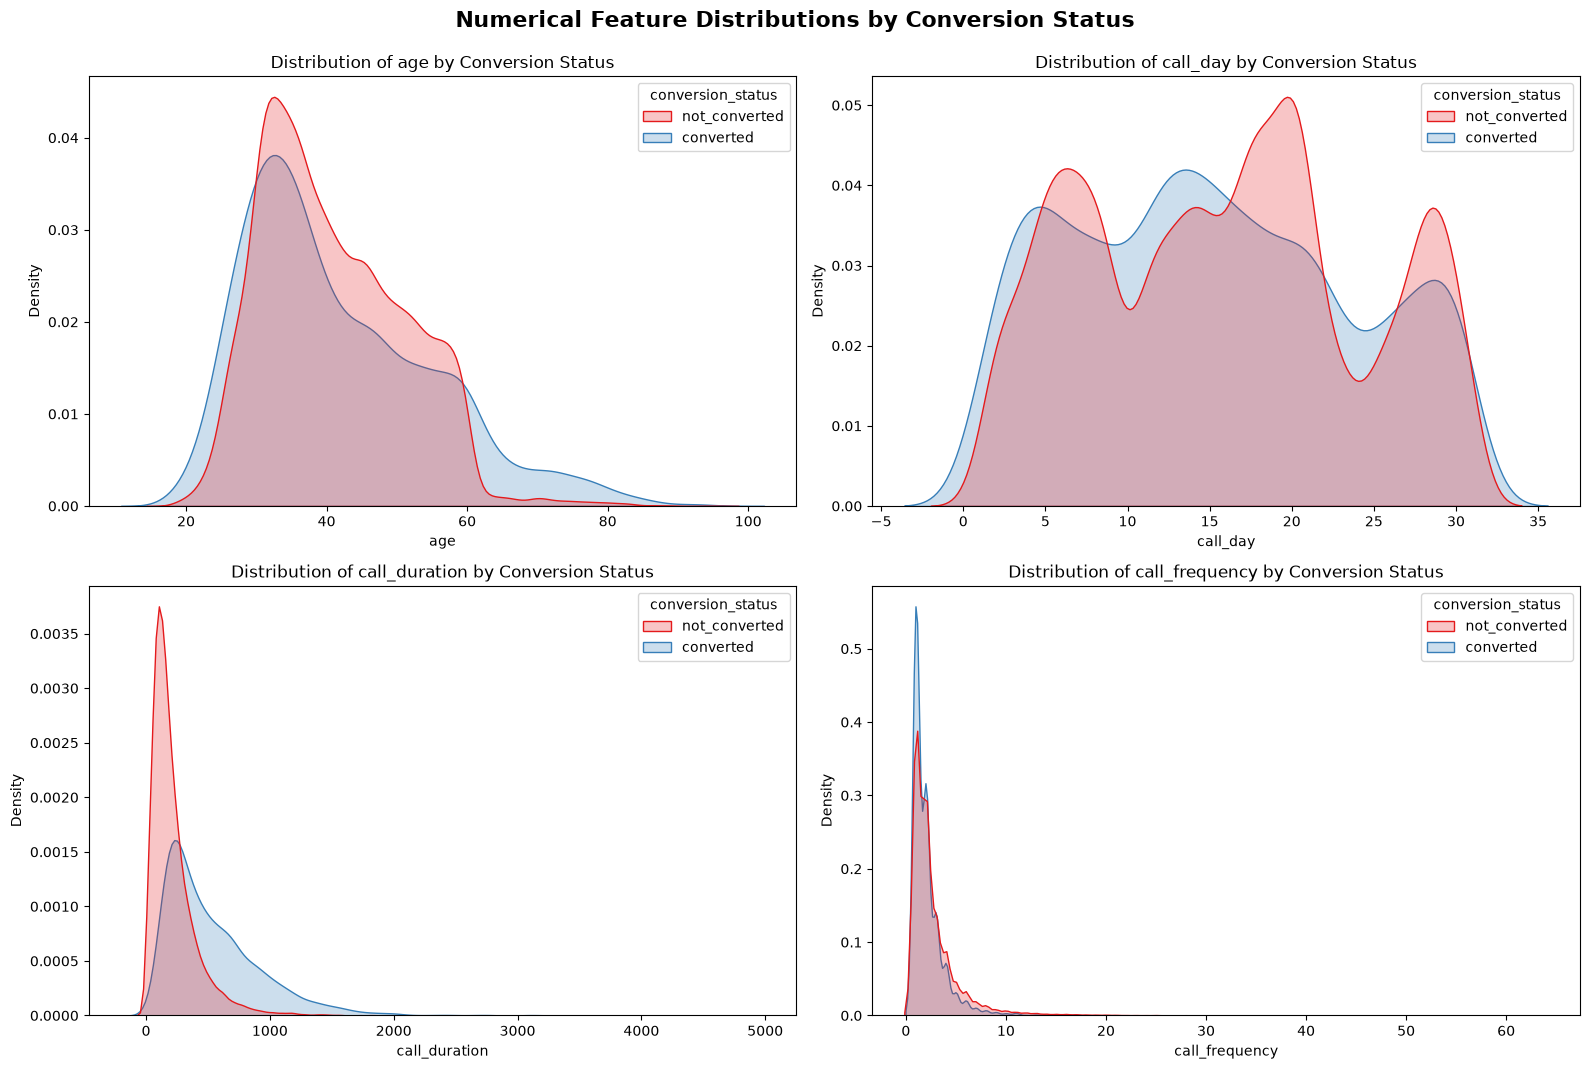

In [302]:
# Visualizing Numerical Feature Distributions by Conversion Status
plt.figure(figsize=(16, 15))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=marketing_data, x=feature, hue='conversion_status', fill=True, common_norm=False, palette='Set1')
    plt.title(f'Distribution of {feature} by Conversion Status')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions by Conversion Status", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/5.numerical_feature_distributions_by_conversion_status.png', bbox_inches='tight')
plt.show()

1. Which customer segments have the highest and lowest marketing conversion rates?

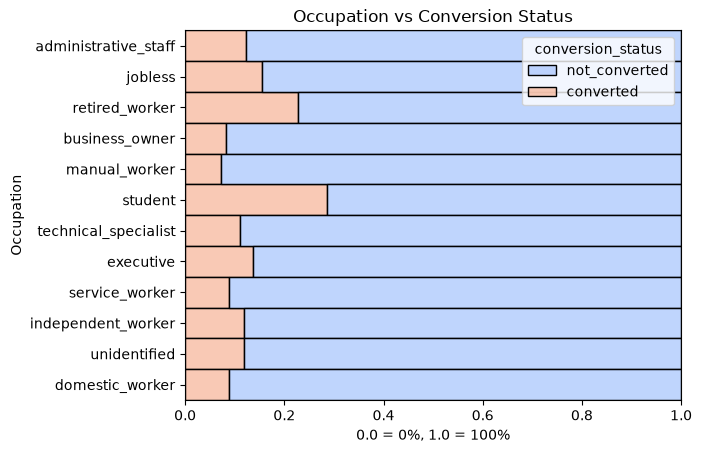

In [303]:
sns.histplot(data=marketing_data, y="occupation", hue="conversion_status", multiple="fill", palette="coolwarm",)
plt.title("Occupation vs Conversion Status")
plt.xlabel("0.0 = 0%, 1.0 = 100%")
plt.ylabel("Occupation")
plt.savefig('../images/6.occupation_vs_conversion_status.png', bbox_inches='tight')
plt.show()

* *students (around 30%) and retired workers (around 23%) have the highest conversion rates while manual worker (around 7%), domestic workers (around 9%) and business owners (around 9%) have lowest marketing conversion rates.*

2. How does customer age influence the likelihood of subscribing to NovaPay’s financial product?

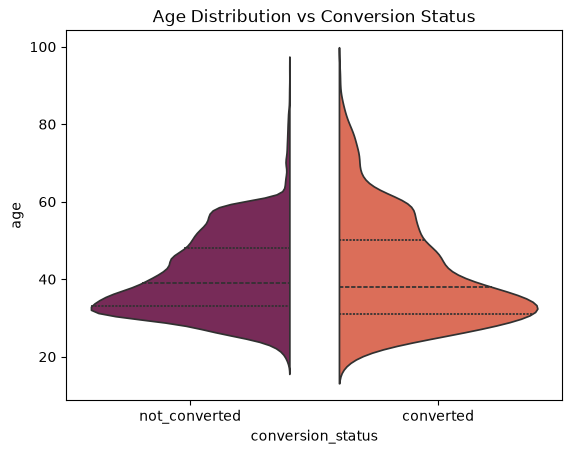

In [304]:
sns.violinplot(x="conversion_status", y="age", hue="conversion_status", data=marketing_data, split=True, inner="quart", palette="rocket",)
plt.title("Age Distribution vs Conversion Status")
plt.savefig('../images/7.age_vs_conversion_status.png', bbox_inches='tight')
plt.show()

* *customers whose age is between 33 to 53 are more likely to be converted*

3. Which marital status segments generate the highest conversion rates?

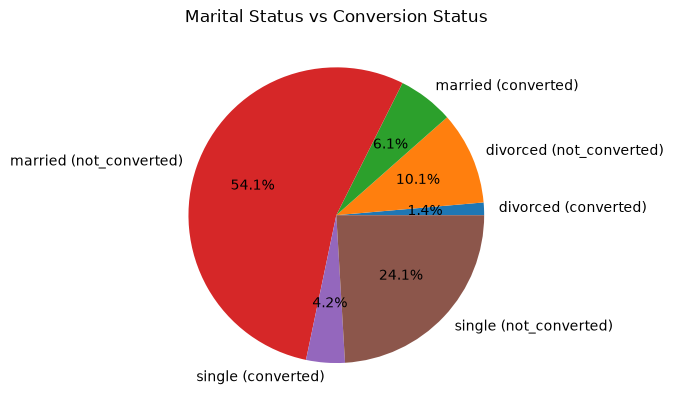

In [305]:
counts = marketing_data.groupby(["marital_status", "conversion_status"]).size()
counts.plot(kind="pie", labels=[f"{ms} ({cs})" for ms, cs in counts.index], autopct="%1.1f%%")
plt.title("Marital Status vs Conversion Status")
plt.savefig('../images/8.marital_status_vs_conversion_status.png', bbox_inches='tight')
plt.show()

* *customers who are married are more likely to convert (approx 6.1%) and customers who are single are yet still likely to convert (4.2%).*

4. Does education level have a meaningful relationship with customer conversion?

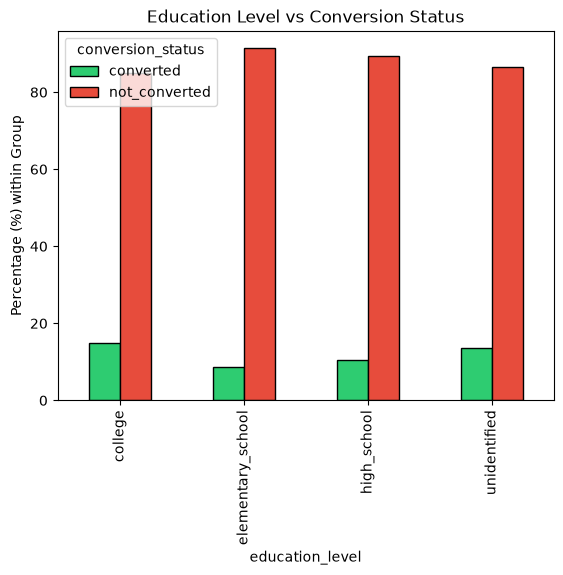

In [317]:
# calculate the percentage table
pct_table = pd.crosstab(marketing_data["education_level"], marketing_data["conversion_status"], normalize="index")
pct_table = pct_table.mul(100)

# generates the plot
ax = pct_table.plot(kind="bar", edgecolor="black", color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Percentage (%) within Group")
plt.title("Education Level vs Conversion Status")
plt.savefig('../images/9.education_level_vs_conversion_status.png', bbox_inches='tight')
plt.show()

* *college has the highest conversion rate (approx 15%).elementary school has the lowest conversion performance (approx 8%). Across every single education_level, over 80% of the customer remains unconverted.*

5. Which marketing contact method produces the highest conversion rate?


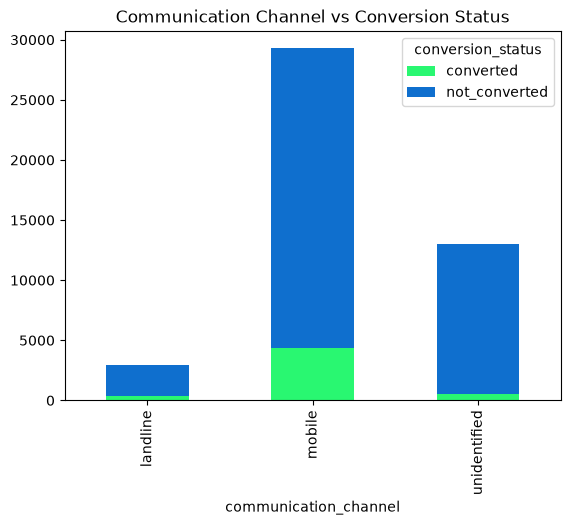

In [307]:
communication = marketing_data.groupby("communication_channel")["conversion_status"].value_counts().unstack()
communication.plot(kind="bar", stacked=True, color=["#29f771", "#0f6fce"])
plt.title("Communication Channel vs Conversion Status")
plt.savefig('../images/10.communication_channel_vs_conversion_status.png', bbox_inches='tight')
plt.show()

* *mobile has the highest conversion rate meanwhile across all three channels (landline, mobile, unidentified), the majority of customers remain not_converted.*

6. Which months or campaign periods generate the strongest and weakest conversion performance?


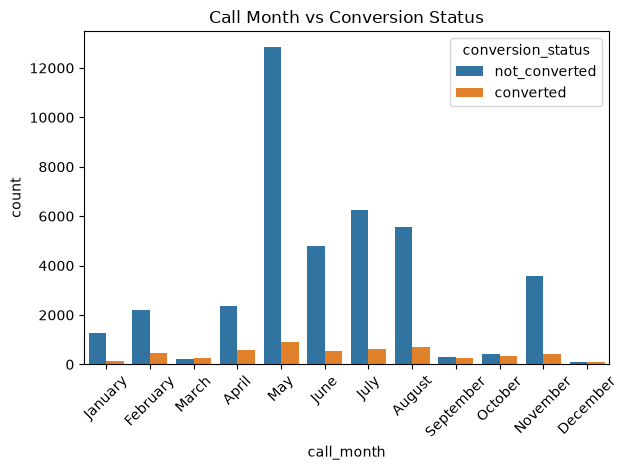

In [308]:
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

sns.countplot(data=marketing_data, x="call_month", hue="conversion_status", order=months)
plt.xticks(rotation=45)
plt.title("Call Month vs Conversion Status")
plt.tight_layout()
plt.savefig('../images/11.call_month_vs_conversion_status.png', bbox_inches='tight')
plt.show()


* *customers who were called in the month of may generates the highest conversion rate followed by june, july and august. customers who were called in the month of december and january generates the least conversion. Meanwhile a majority of customers remains not_converted.*

7. Does the number of times a customer is contacted affect the probability of conversion?


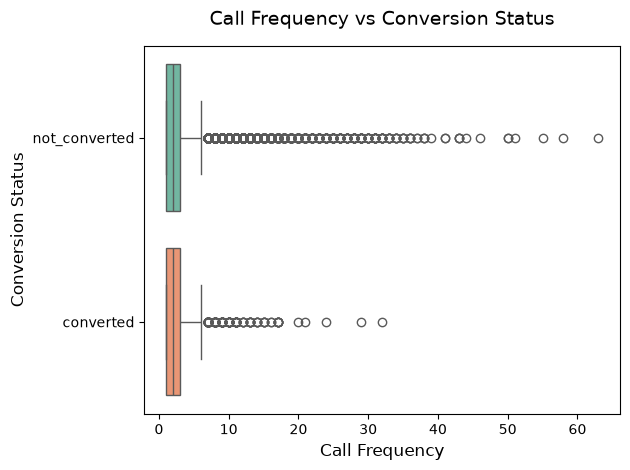

In [309]:
sns.boxplot(data=marketing_data, x='call_frequency', y='conversion_status', palette='Set2', hue='conversion_status')
plt.title('Call Frequency vs Conversion Status', fontsize=14, pad=15)
plt.xlabel('Call Frequency', fontsize=12)
plt.ylabel('Conversion Status', fontsize=12)
plt.tight_layout()
plt.savefig('../images/12.call_frequency_vs_conversion_status.png', bbox_inches='tight')
plt.show()

*No, high contact frequency does not increases conversion. Both groups share a similarly low median call frequency (1–3 calls). excess calling is literally worthless with extreme outliers (30+ calls) in not_converted customers.*

8. How does a customer’s previous campaign outcome influence their likelihood of converting in the current campaign?


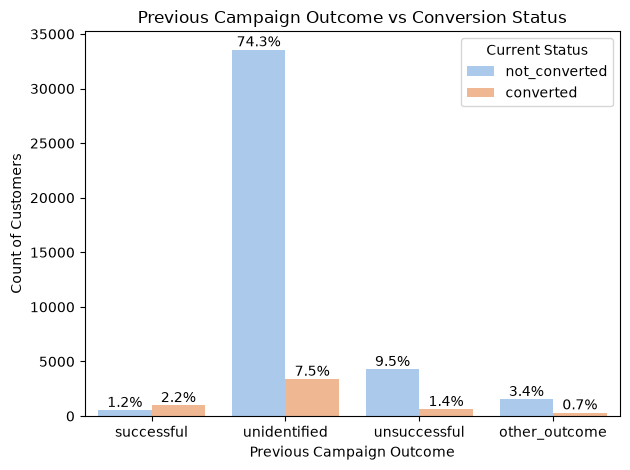

In [310]:
ax = sns.countplot(data=marketing_data, x="previous_campaign_outcome", hue="conversion_status", palette="pastel")

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{(x/len(marketing_data))*100:.1f}%' if x > 0 else '')

plt.title("Previous Campaign Outcome vs Conversion Status")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Count of Customers")
plt.legend(title="Current Status")
plt.tight_layout()
plt.savefig('../images/13.previous_campaign_outcome_vs_conversion_status.png', bbox_inches='tight')
plt.show()


* *The unidentified and unsuccessful campaign outcome has the highest customer count but a poor converted rate, while successful strongly predicts converted, as it is the only category where converted beats not-converted.*

9. Which customer characteristics are most strongly associated with successful conversions?


In [311]:
marketing_data.columns

Index(['occupation', 'age', 'education_level', 'marital_status',
       'communication_channel', 'call_month', 'call_day', 'call_duration',
       'call_frequency', 'previous_campaign_outcome', 'conversion_status'],
      dtype='str')

In [312]:
# Created feature is_converted to highlight successfull conversion
marketing_data["is_converted"] = (marketing_data["conversion_status"] == "converted").astype(int)

# Created feature age_group to group different ages
marketing_data['age_group'] = pd.cut(
    marketing_data['age'], 
    bins=[0, 25, 35, 45, 55, 65, 100], 
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

customer_features = ['occupation', 'age_group', 'education_level', 'marital_status']


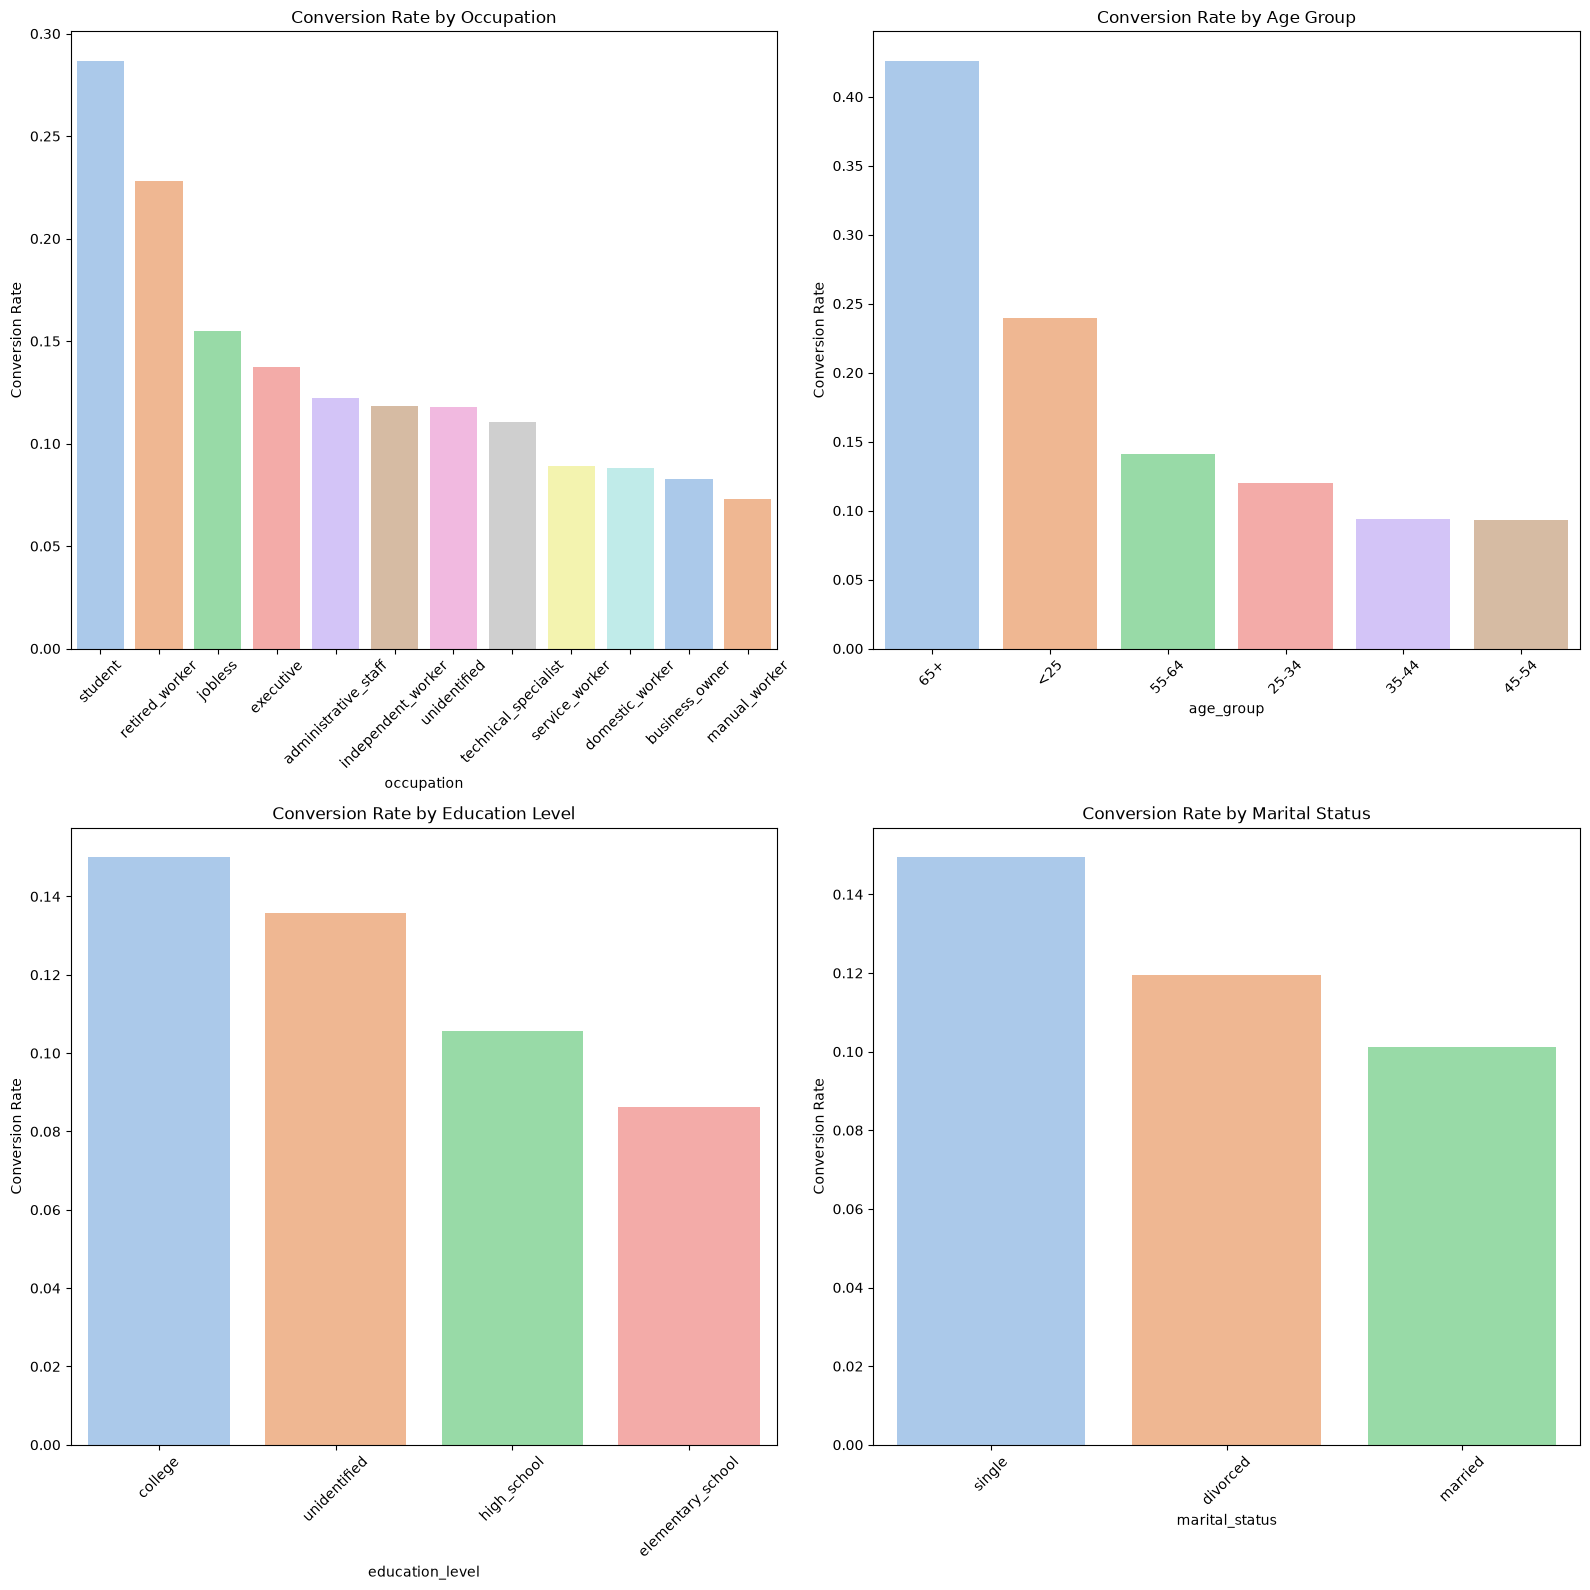

In [313]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for i, x in enumerate(customer_features):
    order = (marketing_data.groupby(x)["is_converted"].mean().sort_values(ascending=False).index)

    sns.barplot(
        data=marketing_data,
        x=x,
        y="is_converted",
        order=order,
        errorbar=None,
        palette="pastel",
        ax=axes[i],
    )

    axes[i].set_title(f"Conversion Rate by {x.replace('_', ' ').title()}")
    axes[i].set_ylabel("Conversion Rate")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig('../images/14.successfull_conversion_rates.png', bbox_inches='tight')
plt.show()


* *students and retired workers shows top converting occupations.*
* *age groups of 65+ and <25 shows high conversion rates.*
* *college individuals show the highest academic conversion rates.*
* *single marital status shows better conversion rates than divorce and married.*

10. Based on the analysis, which customer segments and marketing strategies should NovaPay prioritize to improve overall conversion rates?

In [314]:
marketing_categorical = ['communication_channel', 'call_month']
marketing_numerical = ['call_duration', 'call_frequency', 'call_day']

In [315]:
# merged all important features in important features
important_features = [(f, "bar") for f in customer_features + marketing_categorical] + [(f, "kde") for f in marketing_numerical]
important_features

[('occupation', 'bar'),
 ('age_group', 'bar'),
 ('education_level', 'bar'),
 ('marital_status', 'bar'),
 ('communication_channel', 'bar'),
 ('call_month', 'bar'),
 ('call_duration', 'kde'),
 ('call_frequency', 'kde'),
 ('call_day', 'kde')]

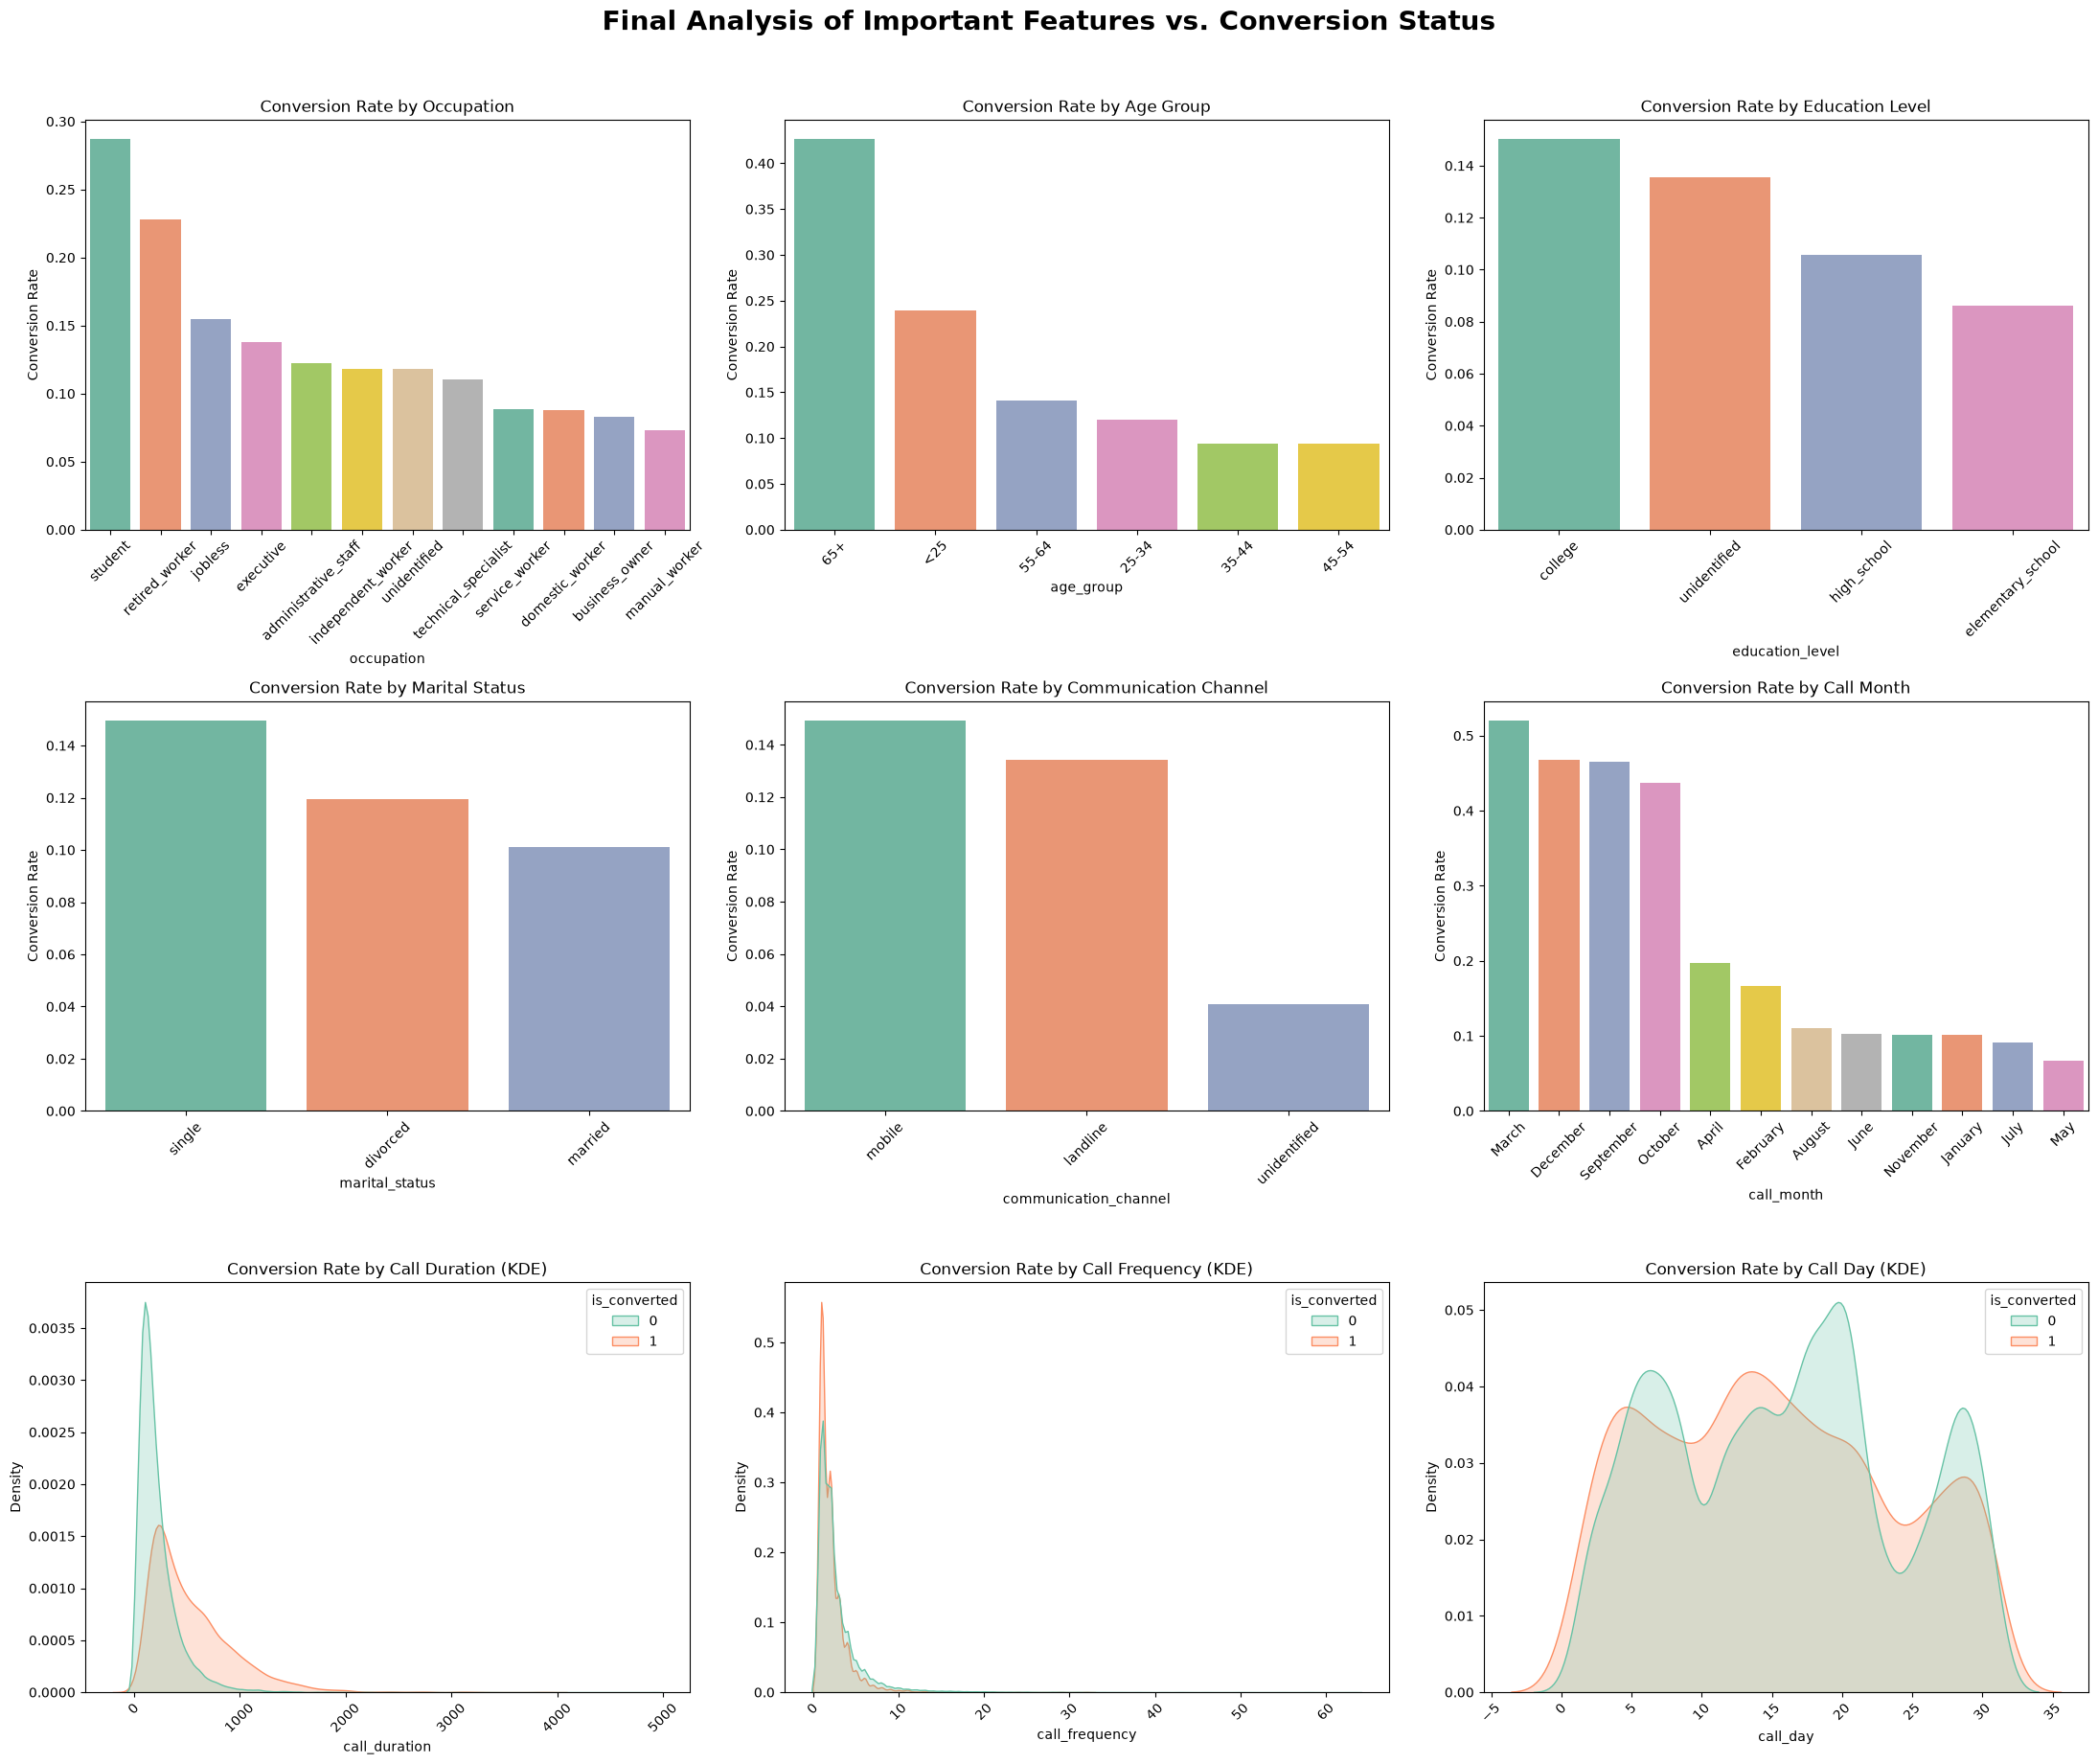

In [316]:
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Final Analysis of Important Features vs. Conversion Status', fontsize=20, fontweight='bold', y=1.02)

for i, (feature, plot_type) in enumerate(important_features):
    ax = axes.flatten()[i]
    
    if plot_type == "bar":
        order = marketing_data.groupby(feature)["is_converted"].mean().sort_values(ascending=False).index
        sns.barplot(data=marketing_data, x=feature, y="is_converted", order=order, errorbar=None, palette="Set2", ax=ax)
        ax.set_title(f"Conversion Rate by {feature.replace('_', ' ').title()}")
        ax.set_ylabel("Conversion Rate")
    else:
        sns.kdeplot(data=marketing_data, x=feature, hue='is_converted', fill=True, common_norm=False, palette='Set2', ax=ax)
        ax.set_title(f"Conversion Rate by {feature.replace('_', ' ').title()} (KDE)")
        
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig('../images/15.Important_Feature_Analysis.png', bbox_inches='tight')
plt.show()


* **Customer Segments:** *target students and the 65+ age group, as they shows the highest conversion rates and also focus on individuals with a college education and those who are single.*
* **Marketing Strategies:** *prioritize mobile communication channels over landlines. schedule campaigns heavily during march, december, and september, while keeping call durations short for optimal efficiency.*